# Webinar 2 — Matrices
**Álgebra lineal aplicada para Data Science**

---

## Agenda
| # | Bloque |
|---|--------|
| 1 | El dataset como matriz | 
| 2 | Operaciones matriciales | 
| 3 | Transposición y multiplicación |
| 4 | Proyección ortogonal | 
| 5 | PCA y embeddings | 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

---
## Parte 1 — El dataset ES una matriz

Cuando pasas un DataFrame a sklearn, lo que viaja internamente es una **matriz NumPy**: filas = observaciones, columnas = features.

In [3]:
casas_data = {
    'm2':          [120, 85,  200, 65,  150],
    'habitaciones':[3,   2,   4,   1,   3  ],
    'dist_centro': [2.5, 1.2, 5.0, 0.8, 3.1],
    'precio':      [250000, 180000, 410000, 140000, 290000],
}

df = pd.DataFrame(casas_data)
X  = df.values

print(f"Shape: {X.shape}  →  {X.shape[0]} filas × {X.shape[1]} columnas")
df

Shape: (5, 4)  →  5 filas × 4 columnas


,m2,habitaciones,dist_centro,precio
0,120,3,2.5,250000
1,85,2,1.2,180000
2,200,4,5.0,410000
3,65,1,0.8,140000
4,150,3,3.1,290000


In [4]:
# Indexing básico
print(f"Casa 1, dist_centro : {X[1, 2]}")
print(f"Primera casa (fila 0): {X[0, :]}")
print(f"Todos los precios    : {X[:, 3]}")

Casa 1, dist_centro : 1.2
Primera casa (fila 0): [1.2e+02 3.0e+00 2.5e+00 2.5e+05]
Todos los precios    : [250000. 180000. 410000. 140000. 290000.]


---
## Parte 2 — Operaciones matriciales

NumPy opera **elemento a elemento** cuando los shapes coinciden.  
**Broadcasting** permite operar un vector sobre todas las filas sin loops.

In [5]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])
B = np.array([[7, 8, 9],
              [1, 2, 3]])

print("A + B\n", A + B)
print("\n3 * A\n", 3 * A)
print("\nA * B  (Hadamard — elem×elem, ≠ producto matricial)\n", A * B)

A + B
 [[ 8 10 12]
 [ 5  7  9]]

3 * A
 [[ 3  6  9]
 [12 15 18]]

A * B  (Hadamard — elem×elem, ≠ producto matricial)
 [[ 7 16 27]
 [ 4 10 18]]


---
## Parte 3 — Transposición y multiplicación matricial

Estas dos operaciones aparecen en casi todo sklearn: regresión lineal, PCA, similitud coseno.

In [7]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

print(f"A     shape: {A.shape}\n{A}")
print(f"\nA.T   shape: {A.T.shape}\n{A.T}")

A     shape: (2, 3)
[[1 2 3]
 [4 5 6]]

A.T   shape: (3, 2)
[[1 4]
 [2 5]
 [3 6]]


In [ ]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])
B = np.array([[7,  8],
              [9,  10],
              [11, 12]])

C = A @ B  
print(f"A: {A.shape},  B: {B.shape}  →  C: {C.shape}")
print("C =\n", C)

A: (2, 3),  B: (3, 2)  →  C: (2, 2)
C =
 [[ 58  64]
 [139 154]]


---
## Parte 4 — Proyección ortogonal

Una **proyección ortogonal** toma un punto y lo "aplana" sobre un subespacio (una línea, un plano).  
La fórmula para proyectar el vector **x** sobre el vector unitario **u** es:

$$\text{proj}_{\mathbf{u}} \mathbf{x} = (\mathbf{x} \cdot \mathbf{u})\, \mathbf{u}$$

O en forma matricial (para proyectar toda una matriz de puntos sobre una dirección):

$$X_{\text{proj}} = X \mathbf{u} \mathbf{u}^T$$

Esto es exactamente lo que hace PCA: busca las **mejores direcciones** (las que capturan más varianza) y proyecta los datos sobre ellas.

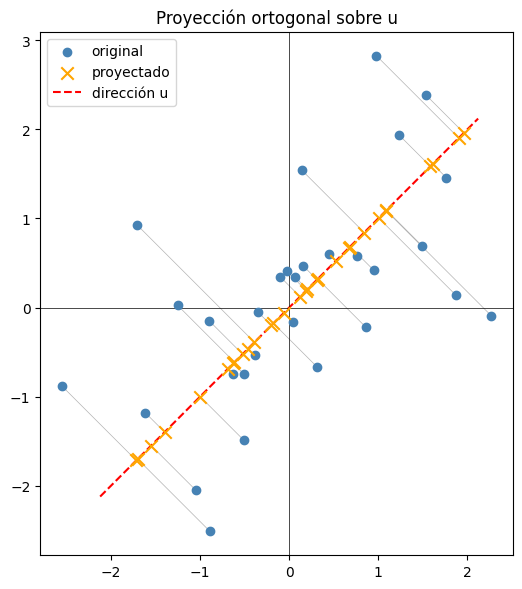

In [10]:
# Proyección de puntos 2D sobre una línea arbitraria
np.random.seed(0)
X2 = np.random.randn(30, 2)
X2[:, 1] += 0.6 * X2[:, 0]   # correlación artificial

# Dirección sobre la que proyectamos (vector unitario, 45°)
u = np.array([1, 1]) / np.sqrt(2)

# Coordenadas escalares (cuánto cae cada punto en esa dirección)
coords = X2 @ u               # shape (30,)

# Puntos proyectados en 2D
X_proj = np.outer(coords, u)  # (30,1) x (1,2) → (30,2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(*X2.T, color='steelblue', label='original', zorder=3)
ax.scatter(*X_proj.T, color='orange', marker='x', s=80, label='proyectado', zorder=3)
for p, q in zip(X2, X_proj):
    ax.plot([p[0], q[0]], [p[1], q[1]], 'gray', lw=0.5, alpha=0.6)
t = np.linspace(-3, 3, 100)
ax.plot(t * u[0], t * u[1], 'r--', lw=1.5, label='dirección u')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title("Proyección ortogonal sobre u")
plt.tight_layout(); plt.show()

In [11]:
# La clave: cuánta varianza captura esa proyección
print(f"Varianza de los datos originales: eje X = {X2[:,0].var():.3f}, eje Y = {X2[:,1].var():.3f}")
print(f"Varianza capturada por la proyección sobre u = {coords.var():.3f}")

# ¿Podemos encontrar la dirección que MAXIMIZA la varianza capturada?
# → Eso es exactamente PCA.

Varianza de los datos originales: eje X = 1.290, eje Y = 1.374
Varianza capturada por la proyección sobre u = 2.067


---
## Parte 5 — PCA y embeddings

**PCA** busca automáticamente las direcciones (componentes principales) que capturan la mayor varianza.  
Matemáticamente son los **eigenvectores** de la matriz de covarianza $X^T X$.

Proyectar sobre los primeros $k$ componentes es una forma de **reducción de dimensionalidad**:  
pasamos de $n$ features a $k$ coordenadas que resumen la mayor parte de la información.

Esto conecta directamente con los **embeddings** en NLP y visión:  
Word2Vec, GloVe, BERT, etc. aprenden matrices de proyección $W$ tales que  
$\text{embedding}(x) = x W$  
— exactamente una proyección, pero aprendida en vez de calculada con eigenvectores.

In [14]:
# Dataset sintético: 3 features con correlación (reducible a 2D)
X3 = np.random.randn(200, 3)
X3[:, 1] = X3[:, 0] * 2 + np.random.randn(200) * 0.3   # feature 2 ≈ 2 × feature 1
X3[:, 2] = X3[:, 0] * -1 + np.random.randn(200) * 0.3  # feature 3 ≈ -feature 1

pca = PCA()
pca.fit(X3)

print("Varianza explicada por cada componente:")
for i, v in enumerate(pca.explained_variance_ratio_):
    bar = "█" * int(v * 40)
    print(f"  PC{i+1}: {v:.1%}  {bar}")

Varianza explicada por cada componente:
  PC1: 98.6%  ███████████████████████████████████████
  PC2: 1.1%  
  PC3: 0.3%  


Shape original  : (200, 3)
Shape comprimido: (200, 2)
Varianza retenida: 99.7%


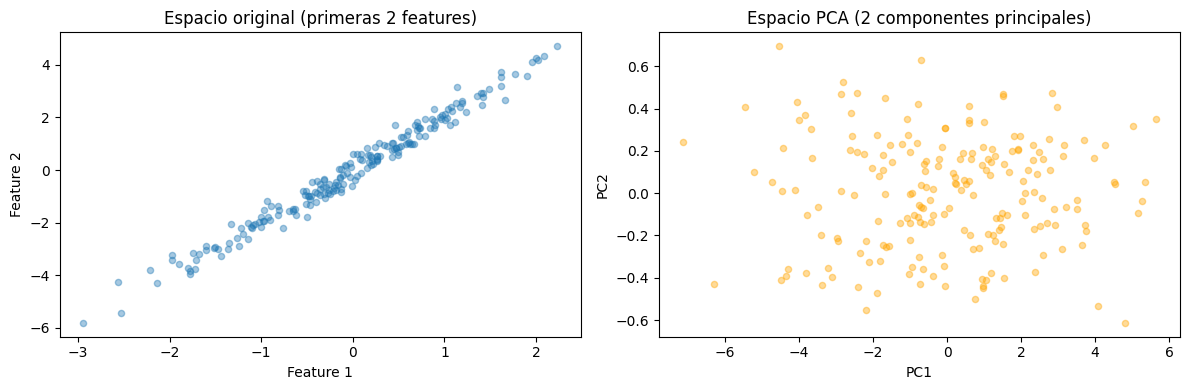

In [15]:
# Proyectar a 2 dimensiones
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X3)

print(f"Shape original  : {X3.shape}")
print(f"Shape comprimido: {X_pca.shape}")
print(f"Varianza retenida: {pca2.explained_variance_ratio_.sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(*X3[:, :2].T, alpha=0.4, s=20)
axes[0].set_title("Espacio original (primeras 2 features)")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

axes[1].scatter(*X_pca.T, alpha=0.4, s=20, color='orange')
axes[1].set_title("Espacio PCA (2 componentes principales)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout(); plt.show()

---
## Resumen

| Concepto | Código | Para qué sirve |
|---|---|---|
| **Matriz** | `np.array([[...]])` | Representar el dataset |
| **Transpuesta** | `A.T` | Girar ejes; necesaria para `A @ A.T` |
| **Mult. matricial** | `A @ B` | Transformar datos; similitud coseno |
| **Broadcasting** | `X - X.mean(axis=0)` | Operar vectores sobre matrices sin loops |
| **Proyección ortogonal** | `X @ u` | Reducir dimensiones; base de PCA |
| **PCA** | `PCA(n_components=k)` | Encontrar las mejores direcciones de proyección |
| **Embeddings** | `x @ W` | Proyección aprendida (Word2Vec, BERT…) |

---
### Próximo webinar
**Distancias: KNN desde cero para detección de fraude bancario.**